# Stylizing ViT - Inference & Style Transfer Demo

This notebook demonstrates how to load a pretrained **Stylizing ViT** model and perform style transfer between two images.

We will use images from the [Fitzpatrick17k](https://github.com/mattgroh/fitzpatrick17k) dataset, fetched directly from their URLs.

In [31]:
import torch
import requests
import pandas as pd
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from torchvision import transforms

# Import the library
from stylizing_vit import create_model
from stylizing_vit.util import denormalize_image

In [32]:
import random
import numpy as np

# Set seeds for reproducibility
SEED = 11
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 11


## 1. Helper Functions

We define a few helpers to download images and preprocess them for the model.

In [33]:
def load_image_from_url(url):
    """Downloads an image from a URL and converts it to RGB."""
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
        return img
    except Exception as e:
        print(f"Error loading image from {url}: {e}")
        return None

# Get dataset mean and std
DATASET_MEAN = (0.6219, 0.4917, 0.4478)
DATASET_STD = (0.2279, 0.1982, 0.1991)

# Standard ImageNet normalization (used by default in Stylizing ViT)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])

## 2. Load the Dataset Metadata

We fetch the Fitzpatrick17k CSV file to get image URLs.

In [34]:
csv_url = "https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/refs/heads/main/fitzpatrick17k.csv"
df = pd.read_csv(csv_url)

# Filter for rows that have a valid URL
df = df[df['url'].notna()]
print(f"Loaded dataset metadata with {len(df)} images.")

Loaded dataset metadata with 16536 images.


## 3. Load Pretrained Model

We load the `base` model pretrained on Fitzpatrick17k. The weights are automatically downloaded from the Hugging Face Hub.

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Weights Identifier from the README table
WEIGHTS_ID = "fitzpatrick17k"

model = create_model(backbone="small", weights=WEIGHTS_ID, train=False)
model = model.to(device)
model.eval()
print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


## 4. Run Style Transfer

We pick two random images from the dataset: one to serve as **Content**, the other as **Style**.

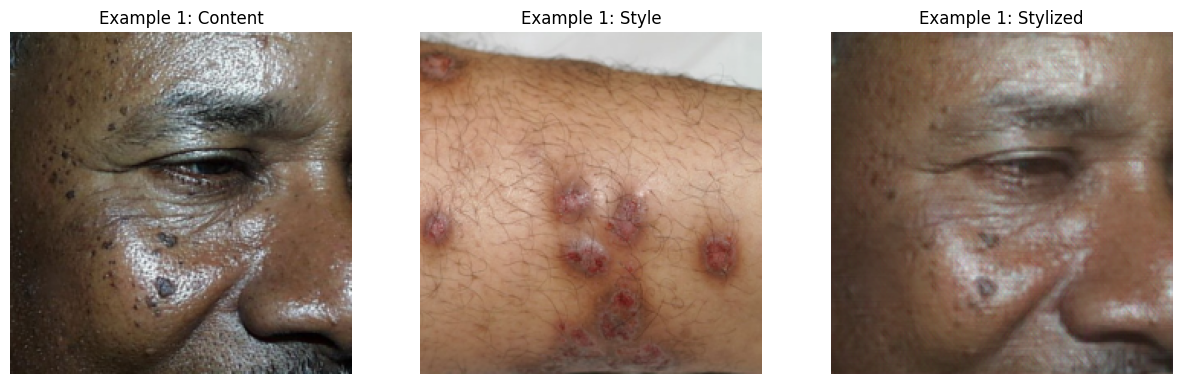

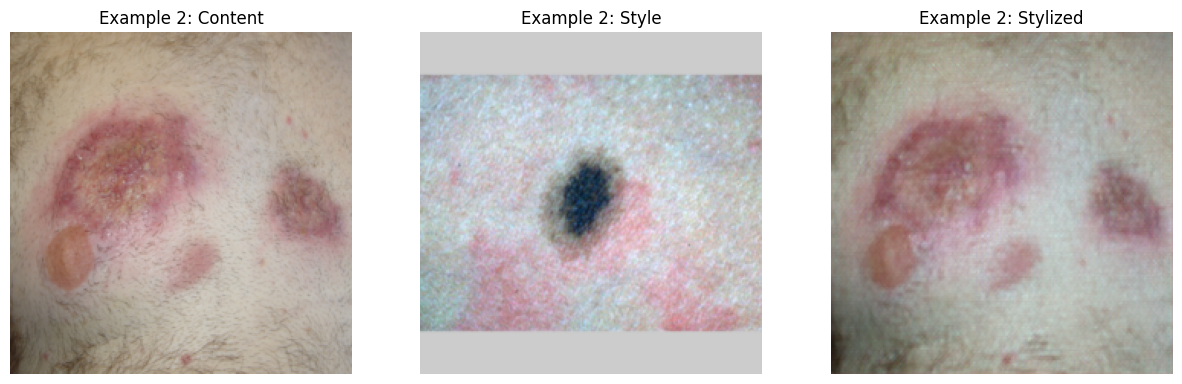

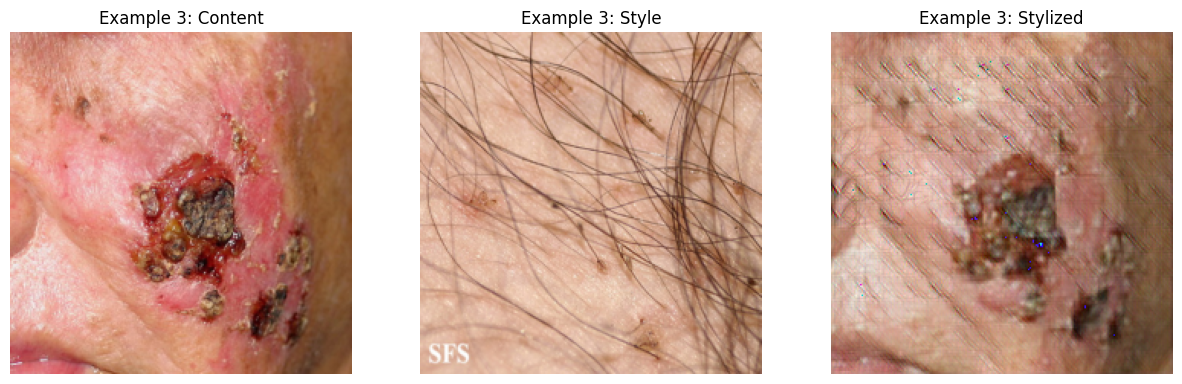

In [36]:
# Number of examples to show
NUM_EXAMPLES = 3

for i in range(NUM_EXAMPLES):
    # Sample two valid images
    content_img = None
    style_img = None

    # Retry loop in case of broken links
    while content_img is None or style_img is None:
        sample = df.sample(2)
        url_c = sample.iloc[0]['url']
        url_s = sample.iloc[1]['url']
        
        content_pil = load_image_from_url(url_c)
        style_pil = load_image_from_url(url_s)
        
        if content_pil and style_pil:
            # Transform to tensor (1, 3, 224, 224)
            content_img = transform(content_pil).unsqueeze(0).to(device)
            style_img   = transform(style_pil).unsqueeze(0).to(device)

    # Run Inference
    with torch.no_grad():
        # Forward pass: Stylizes content_img with style_img
        # Also returns attention maps (attn) which we ignore here
        stylized = model(content_img, style_img)

    # Post-process for display
    tensor_c = denormalize_image(content_img.cpu(), DATASET_MEAN, DATASET_STD)
    tensor_s = denormalize_image(style_img.cpu(), DATASET_MEAN, DATASET_STD)
    tensor_t = denormalize_image(stylized.cpu(), DATASET_MEAN, DATASET_STD)

    # Convert to PIL for easy plotting
    img_c = transforms.ToPILImage()(tensor_c.squeeze(0))
    img_s = transforms.ToPILImage()(tensor_s.squeeze(0))
    img_t = transforms.ToPILImage()(tensor_t.squeeze(0))

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_c)
    axes[0].set_title(f"Example {i+1}: Content")
    axes[0].axis('off')

    axes[1].imshow(img_s)
    axes[1].set_title(f"Example {i+1}: Style")
    axes[1].axis('off')

    axes[2].imshow(img_t)
    axes[2].set_title(f"Example {i+1}: Stylized")
    axes[2].axis('off')

    plt.show()